In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [4]:
def read_decode_depth(depthpath):
    depth_rgba = cv2.imread(depthpath, cv2.IMREAD_UNCHANGED)
    depth = depth_rgba.view("<f4")
    return np.squeeze(depth, axis=-1)

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path
from PIL import Image

data_root = Path("/Volumes/T9/datasets")
depth_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "depth_lcam_front" / "000000_lcam_front_depth.png"
rgb_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "image_lcam_front" / "000000_lcam_front.png"


depth_raw = read_decode_depth(depth_path)  
img_raw = np.array(Image.open(rgb_path))
depth_m = depth_raw.copy().astype(np.float32)
depth_m[depth_m > 20.0] = np.nan

gray = cv2.cvtColor(img_raw, cv2.COLOR_RGB2GRAY).astype(np.float32)



/var/folders/br/cmzzcsb57_98q6bdzbmph71r0000gn/T/ipykernel_7201/2407362395.py:34: RuntimeWarning: divide by zero encountered in log
  dx_d = cv2.Sobel(np.log(depth_filled), cv2.CV_32F, 1, 0, ksize=KSIZE_DIFF)
/var/folders/br/cmzzcsb57_98q6bdzbmph71r0000gn/T/ipykernel_7201/2407362395.py:35: RuntimeWarning: divide by zero encountered in log
  dy_d = cv2.Sobel(np.log(depth_filled), cv2.CV_32F, 0, 1, ksize=KSIZE_DIFF)
/var/folders/br/cmzzcsb57_98q6bdzbmph71r0000gn/T/ipykernel_7201/2407362395.py:43: RuntimeWarning: invalid value encountered in divide
  anisotropy_d = np.where(lam1_d > EPS_RATIO, 1.0 - lam2_d / lam1_d, np.nan)


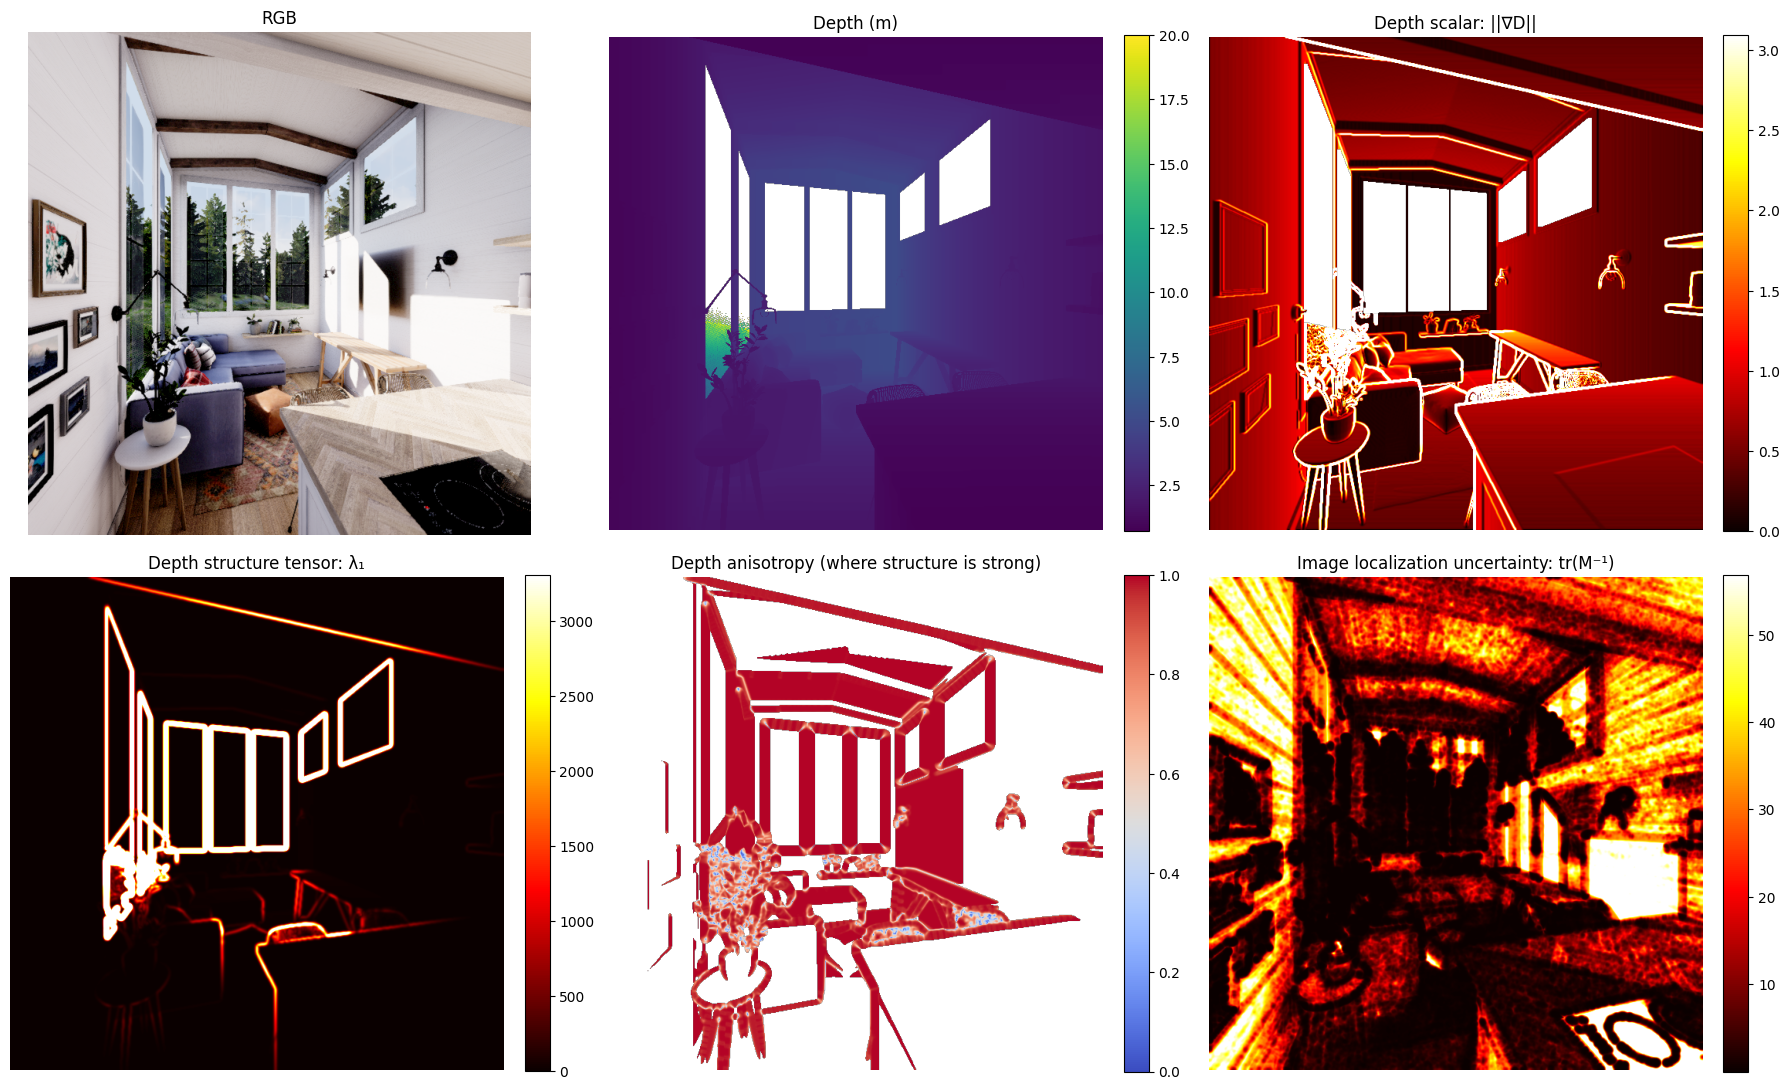

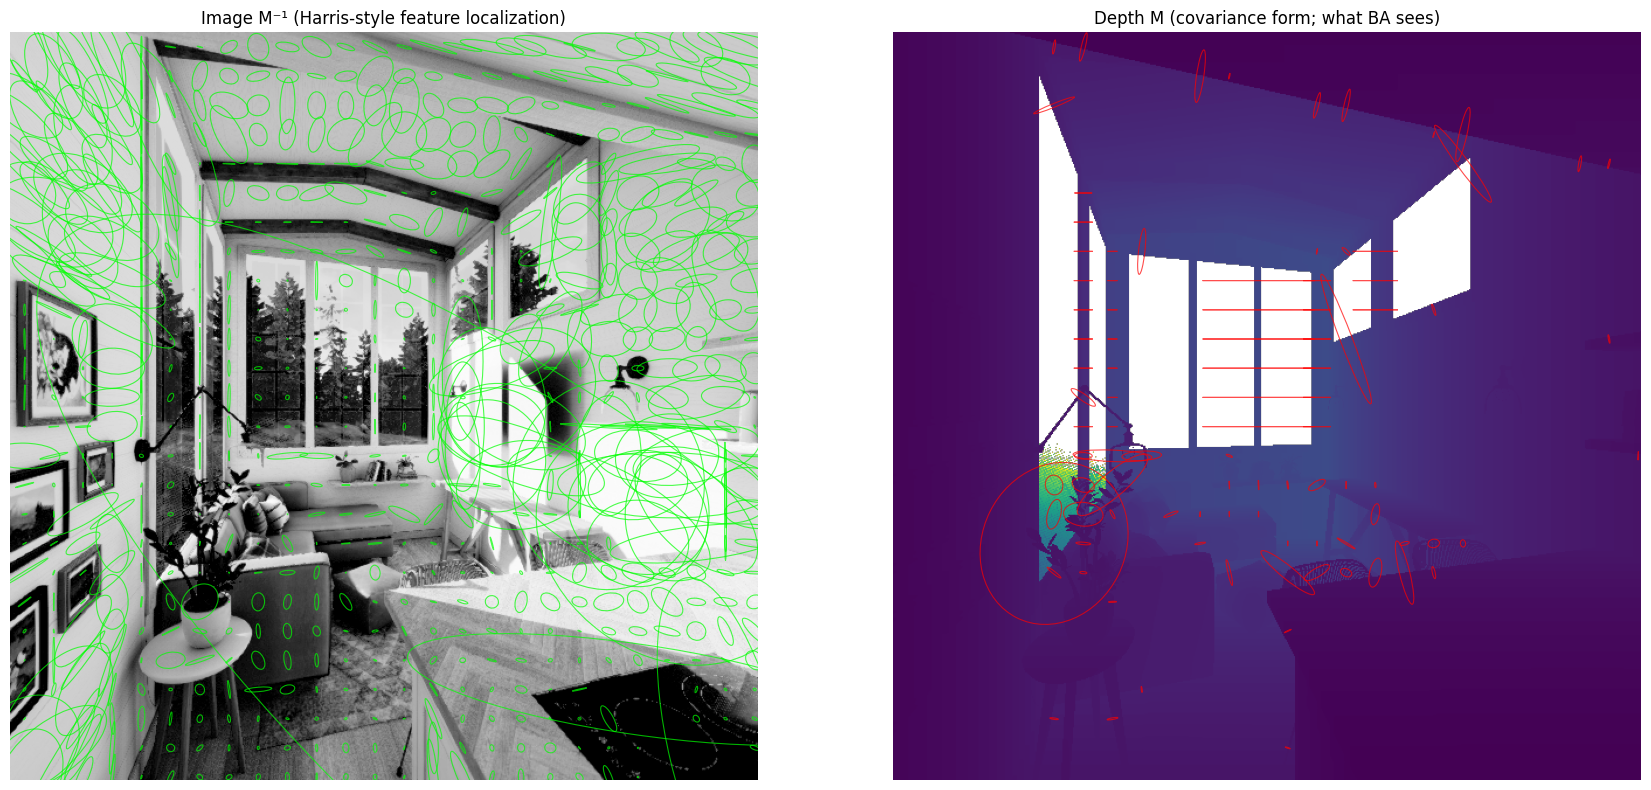

In [6]:
import numpy as np
import cv2
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


KSIZE_DIFF = 5         # differentiation scale (Sobel kernel)
SIGMA_INTEG = 1.5      # integration scale (Gaussian smoothing of products)
EPS_RATIO = 1e-3       # for safe division in ratios

def structure_tensor(field, ksize_diff=KSIZE_DIFF, sigma_integ=SIGMA_INTEG):
    """Compute structure tensor components with explicit two-scale setup."""
    dx = cv2.Sobel(field, cv2.CV_32F, 1, 0, ksize=ksize_diff)
    dy = cv2.Sobel(field, cv2.CV_32F, 0, 1, ksize=ksize_diff)
    Sxx = cv2.GaussianBlur(dx * dx, (0, 0), sigma_integ)
    Syy = cv2.GaussianBlur(dy * dy, (0, 0), sigma_integ)
    Sxy = cv2.GaussianBlur(dx * dy, (0, 0), sigma_integ)
    return Sxx, Sxy, Syy

def eigenvalues_from_tensor(Sxx, Sxy, Syy):
    """Closed-form 2x2 symmetric eigenvalues. Returns (lam_max, lam_min)."""
    trace = Sxx + Syy
    det = Sxx * Syy - Sxy * Sxy
    discriminant = np.sqrt(np.maximum(trace * trace / 4 - det, 0))
    lam_max = trace / 2 + discriminant
    lam_min = trace / 2 - discriminant
    return lam_max, lam_min

# 1. Depth scalar uncertainty
depth_filled = np.where(np.isnan(depth_m), 0, depth_m)
mask_valid = ~np.isnan(depth_m)

dx_d = cv2.Sobel(np.log(depth_filled), cv2.CV_32F, 1, 0, ksize=KSIZE_DIFF)
dy_d = cv2.Sobel(np.log(depth_filled), cv2.CV_32F, 0, 1, ksize=KSIZE_DIFF)
grad_mag = np.sqrt(dx_d**2 + dy_d**2)

# 2. Depth structure tensor
Sxx_d, Sxy_d, Syy_d = structure_tensor(depth_filled)
lam1_d, lam2_d = eigenvalues_from_tensor(Sxx_d, Sxy_d, Syy_d)

# Anisotropy where structure is meaningful
anisotropy_d = np.where(lam1_d > EPS_RATIO, 1.0 - lam2_d / lam1_d, np.nan)

# 3. Image structure tensor (feature-quality only)
gray_float = gray.astype(np.float32) / 255.0
Sxx_i, Sxy_i, Syy_i = structure_tensor(gray_float)
lam1_i, lam2_i = eigenvalues_from_tensor(Sxx_i, Sxy_i, Syy_i)

# Image localization uncertainty: tr(M^-1), interpreted as inverse-corner-strength
# Use scale-appropriate epsilon based on typical eigenvalue magnitude
eps_img = max(1e-2, 0.01 * np.nanpercentile(lam1_i[lam1_i > 0], 50))
unc_img_scalar = 1.0 / (lam1_i + eps_img) + 1.0 / (lam2_i + eps_img)



#Visualization: scalar maps 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0, 0].imshow(img_raw); axes[0, 0].set_title("RGB")
im1 = axes[0, 1].imshow(depth_m, cmap="viridis"); axes[0, 1].set_title("Depth (m)")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(grad_mag, cmap="hot",
                         vmax=np.nanpercentile(grad_mag, 95))
axes[0, 2].set_title("Depth scalar: ||∇D||")
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(lam1_d, cmap="hot",
                         vmax=np.nanpercentile(lam1_d, 95))
axes[1, 0].set_title("Depth structure tensor: λ₁")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Mask anisotropy where structure is weak (visualization sanity)
anisotropy_meaningful = np.where(
    lam1_d > np.nanpercentile(lam1_d, 70),
    anisotropy_d,
    np.nan
)
im4 = axes[1, 1].imshow(anisotropy_meaningful, cmap="coolwarm", vmin=0, vmax=1)
axes[1, 1].set_title("Depth anisotropy (where structure is strong)")
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(unc_img_scalar, cmap="hot",
                         vmax=np.nanpercentile(unc_img_scalar, 95))
axes[1, 2].set_title("Image localization uncertainty: tr(M⁻¹)")
fig.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()


#Visualization: ellipses
def draw_ellipses(ax, Sxx, Sxy, Syy, mask, mode, step=25, color="lime",
                   global_scale=None, title=""):
    """
    Draw structure tensor ellipses.
    
    mode='inverse':  Draw M^-1 (Harris-style feature localization).
                     Large M eigenvalue → small ellipse → well-localized.
    mode='direct':   Draw M itself (depth fragility as it enters BA).
                     Large M eigenvalue → large ellipse → high variance.
    """
    ax.set_title(title)
    h, w = Sxx.shape
    
    if global_scale is None:
        # Auto: scale ellipses to fit step size on average
        eig_vals_all = []
        for y in range(step // 2, h, step):
            for x in range(step // 2, w, step):
                if not mask[y, x]: continue
                M = np.array([[Sxx[y, x], Sxy[y, x]],
                              [Sxy[y, x], Syy[y, x]]])
                ev = np.linalg.eigvalsh(M)
                eig_vals_all.append(ev)
        eig_vals_all = np.array(eig_vals_all).flatten()
        eig_vals_all = eig_vals_all[eig_vals_all > 1e-6]
        if mode == 'direct':
            global_scale = step / (3 * np.sqrt(np.nanmedian(eig_vals_all)))
        else:  # inverse
            global_scale = step * np.sqrt(np.nanmedian(eig_vals_all)) / 3
    
    for y in range(step // 2, h, step):
        for x in range(step // 2, w, step):
            if not mask[y, x]: continue
            
            M = np.array([[Sxx[y, x], Sxy[y, x]],
                          [Sxy[y, x], Syy[y, x]]])
            eigvals, eigvecs = np.linalg.eigh(M)
            eigvals = np.clip(eigvals, 1e-6, None)
            
            if mode == 'inverse':
                # M^-1 covariance: ellipse axes = sqrt(1/eigval) = 1/sqrt(eigval)
                widths = global_scale / np.sqrt(eigvals)
            elif mode == 'direct':
                # M as covariance: ellipse axes = sqrt(eigval)
                widths = global_scale * np.sqrt(eigvals)
            
            # Eigenvectors: eigh returns ascending order. eigvecs[:, 1] is for larger eigenvalue.
            angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
            ell = Ellipse(xy=(x, y),
                          width=widths[1],
                          height=widths[0],
                          angle=angle, fill=False,
                          edgecolor=color, linewidth=0.8, alpha=0.7)
            ax.add_patch(ell)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(gray, cmap="gray")
draw_ellipses(axes[0], Sxx_i, Sxy_i, Syy_i,
              np.ones_like(gray, dtype=bool),
              mode='inverse', color="lime",
              title="Image M⁻¹ (Harris-style feature localization)")

# For depth, only show top-strength pixels to declutter
depth_strength = lam1_d
strength_threshold = np.nanpercentile(depth_strength[mask_valid], 85)
depth_show_mask = mask_valid & (depth_strength > strength_threshold)

axes[1].imshow(depth_m, cmap="viridis")
draw_ellipses(axes[1], Sxx_d, Sxy_d, Syy_d, depth_show_mask,
              mode='direct', color="red",
              title="Depth M (covariance form; what BA sees)")

for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Analysis of reprojection residuals

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from scipy.ndimage import distance_transform_edt



# Feature detection and matching

def get_kps_descriptors(image):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    sift = cv2.SIFT_create()
    return sift.detectAndCompute(gray, None)


def match(image_1, image_2, ratio_threshold=0.75, cross_check=True,
          geometric_verification=True, ransac_threshold=3.0,
          ransac_confidence=0.999, K=None):
    kps1, desc1 = get_kps_descriptors(image_1)
    kps2, desc2 = get_kps_descriptors(image_2)
    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return [], kps1, kps2, None

    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches_12 = flann.knnMatch(desc1, desc2, k=2)
    good_12 = {}
    for pair in matches_12:
        if len(pair) < 2: continue
        m, n = pair
        if m.distance < ratio_threshold * n.distance:
            good_12[m.queryIdx] = m

    if cross_check:
        matches_21 = flann.knnMatch(desc2, desc1, k=2)
        good_21 = {}
        for pair in matches_21:
            if len(pair) < 2: continue
            m, n = pair
            if m.distance < ratio_threshold * n.distance:
                good_21[m.queryIdx] = m
        candidate_matches = [m12 for m12 in good_12.values()
                             if m12.trainIdx in good_21
                             and good_21[m12.trainIdx].trainIdx == m12.queryIdx]
    else:
        candidate_matches = list(good_12.values())

    if not geometric_verification or len(candidate_matches) < 8:
        return candidate_matches, kps1, kps2, None

    pts1 = np.float32([kps1[m.queryIdx].pt for m in candidate_matches])
    pts2 = np.float32([kps2[m.trainIdx].pt for m in candidate_matches])

    if K is not None:
        E, mask = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC,
                                       prob=ransac_confidence, threshold=ransac_threshold)
    else:
        E, mask = cv2.findFundamentalMat(pts1, pts2, method=cv2.FM_RANSAC,
                                         ransacReprojThreshold=ransac_threshold,
                                         confidence=ransac_confidence)
    if E is None or mask is None:
        return [], kps1, kps2, None
    mask = mask.ravel().astype(bool)
    inlier_matches = [m for m, keep in zip(candidate_matches, mask) if keep]
    return inlier_matches, kps1, kps2, mask


# Geometry

def back_project(pixel, depth, K):
    """Back-project to TartanAir NED frame: X=fwd, Y=right, Z=down."""
    u, v = pixel
    x_pin = (u - K[0, 2]) * depth / K[0, 0]
    y_pin = (v - K[1, 2]) * depth / K[1, 1]
    return np.array([depth, x_pin, y_pin])


def back_project_ray(pixel, K):
    """Unit ray direction in TartanAir camera frame (no depth required)."""
    X = back_project(pixel, 1.0, K)
    return X / np.linalg.norm(X)


def project_point_tartanair(X, K):
    if X[0] <= 0:
        return np.array([np.nan, np.nan])
    return np.array([K[0, 0] * X[1] / X[0] + K[0, 2],
                     K[1, 1] * X[2] / X[0] + K[1, 2]])


def relative_pose(T_w1, T_w2):
    return np.linalg.inv(T_w2) @ T_w1


def transform_point(X, T):
    return (T @ np.append(X, 1.0))[:3]


def quat_to_rotmat(q):
    x, y, z, w = q
    n = np.sqrt(x*x + y*y + z*z + w*w)
    x, y, z, w = x/n, y/n, z/n, w/n
    return np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),         1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),         2*(y*z + x*w),     1 - 2*(x*x + y*y)],
    ])


def pose_quat_to_SE3(pose):
    T = np.eye(4)
    T[:3, :3] = quat_to_rotmat(pose[3:])
    T[:3, 3] = pose[:3]
    return T


def sample_depth_nn(depth_map, pixel):
    u, v = pixel
    u_i, v_i = int(round(u)), int(round(v))
    h, w = depth_map.shape
    if v_i < 0 or v_i >= h or u_i < 0 or u_i >= w:
        return np.nan
    return depth_map[v_i, u_i]


In [8]:
# Driver

data_root = Path("/Volumes/T9/datasets")
base = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000"

depth_path = base / "depth_lcam_front" / "000000_lcam_front_depth.png"
rgb_path = base / "image_lcam_front" / "000000_lcam_front.png"
rgb_path_2 = base / "image_lcam_front" / "000001_lcam_front.png"
gt_file = base / "pose_lcam_front.txt"

# Load depth (uses your existing decoder)
depth_raw = read_decode_depth(depth_path)
depth_m = depth_raw.copy().astype(np.float32)
depth_m[depth_m > 20.0] = np.nan

# Load poses
poses = np.loadtxt(gt_file)
SE3_list = [pose_quat_to_SE3(p) for p in poses]

# Intrinsics: 640x640, 90° FOV → f = 320, cx = cy = 320
K = np.array([
    [320.0,   0.0, 320.0],
    [  0.0, 320.0, 320.0],
    [  0.0,   0.0,   1.0],
])

# Load images
img1 = np.array(Image.open(rgb_path))
img2 = np.array(Image.open(rgb_path_2))



In [9]:
# Compare first pose from each camera
poses_l = np.loadtxt(base / "pose_lcam_front.txt")
poses_r = np.loadtxt(base / "pose_rcam_front.txt")

T_l = pose_quat_to_SE3(poses_l[0])
T_r = pose_quat_to_SE3(poses_r[0])
T_lr = relative_pose(T_l, T_r)
print("T_lr:\n", T_lr)
print("Translation:", T_lr[:3, 3])
print("Rotation:\n", T_lr[:3, :3])

T_lr:
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.81794726e-08]
 [ 2.77555756e-17  1.00000000e+00  0.00000000e+00 -2.49999987e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Translation: [-1.81794726e-08 -2.49999987e-01  0.00000000e+00]
Rotation:
 [[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.77555756e-17 1.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [10]:
import glob

PATCH_SIZE = 32
MAX_DEPTH = 50.0
MAX_ERROR = 50.0
MIN_VALID_RATIO = 0.75  # at least 75% of depth patch must be valid

T_lr = np.eye(4)
T_lr[1, 3] = -0.25

data_root = Path("/Volumes/T9/datasets")
base = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy"

train_sequences = ["P000", "P001", "P002", "P003", "P004"]
test_sequences = ["P005", "P006"]


def extract_patch(array, pixel, size=PATCH_SIZE):
    """Works for both image (H,W,C) and depth (H,W)."""
    half = size // 2
    u_i, v_i = int(round(pixel[0])), int(round(pixel[1]))
    h, w = array.shape[:2]
    if v_i - half < 0 or v_i + half >= h or u_i - half < 0 or u_i + half >= w:
        return None
    return array[v_i - half:v_i + half, u_i - half:u_i + half].copy()


def build_split(sequences, split_name):
    img_patches = []
    depth_patches = []
    errors = []

    for seq in sequences:
        seq_dir = base / seq
        # count frames from available files
        n_frames = len([f for f in (seq_dir / "image_lcam_front").glob("*_lcam_front.png")
                if not f.name.startswith(".")])
        print(f"  {seq}: {n_frames} frames")

        for i in range(n_frames):
            img_l = np.array(Image.open(seq_dir / "image_lcam_front" / f"{i:06d}_lcam_front.png"))
            img_r = np.array(Image.open(seq_dir / "image_rcam_front" / f"{i:06d}_rcam_front.png"))
            depth_l = read_decode_depth(str(seq_dir / "depth_lcam_front" / f"{i:06d}_lcam_front_depth.png"))
            depth_l = depth_l.astype(np.float32)
            depth_l[depth_l > MAX_DEPTH] = np.nan

            good_matches, kps1, kps2, _ = match(img_l, img_r, K=K)

            for m in good_matches:
                pt_a = np.array(kps1[m.queryIdx].pt)
                pt_b_obs = np.array(kps2[m.trainIdx].pt)

                d_a = sample_depth_nn(depth_l, pt_a)
                if np.isnan(d_a) or d_a <= 0 or d_a > MAX_DEPTH:
                    continue

                # extract patches
                p_img = extract_patch(img_l, pt_a)
                if p_img is None:
                    continue
                p_depth = extract_patch(depth_l, pt_a)
                if p_depth is None:
                    continue

                # check depth patch validity
                valid_ratio = np.mean(~np.isnan(p_depth) & (p_depth > 0))
                if valid_ratio < MIN_VALID_RATIO:
                    continue

                # reprojection error
                X_a = back_project(pt_a, d_a, K)
                X_b = transform_point(X_a, T_lr)
                proj_b = project_point_tartanair(X_b, K)
                if np.any(np.isnan(proj_b)):
                    continue

                err = np.linalg.norm(pt_b_obs - proj_b)
                if err > MAX_ERROR:
                    continue

                img_patches.append(p_img)
                depth_patches.append(p_depth)
                errors.append(err)

        print(f"    running total: {len(errors)} samples")

    data = {
        "img_patch": np.stack(img_patches),          # (N, 32, 32, 3) uint8
        "depth_patch": np.stack(depth_patches),       # (N, 32, 32) float32
        "reproj_error": np.array(errors, dtype=np.float32),  # (N,)
    }

    path = f"stereo_dataset_{split_name}.npz"
    np.savez_compressed(path, **data)
    print(f"\n  {split_name}: {len(errors)} samples saved to {path}")
    print(f"  error stats: mean={data['reproj_error'].mean():.2f}, "
          f"median={np.median(data['reproj_error']):.2f}, "
          f"p95={np.percentile(data['reproj_error'], 95):.2f} px")
    return data


print("Building train set...")
train_data = build_split(train_sequences, "train")
print("\nBuilding test set...")
test_data = build_split(test_sequences, "test")

Building train set...
  P000: 116 frames
    running total: 6704 samples
  P001: 120 frames
    running total: 23117 samples
  P002: 134 frames
    running total: 37283 samples
  P003: 152 frames
    running total: 51353 samples
  P004: 135 frames
    running total: 64836 samples

  train: 64836 samples saved to stereo_dataset_train.npz
  error stats: mean=1.43, median=0.49, p95=5.03 px

Building test set...
  P005: 118 frames
    running total: 11312 samples
  P006: 91 frames
    running total: 18928 samples

  test: 18928 samples saved to stereo_dataset_test.npz
  error stats: mean=1.50, median=0.50, p95=5.94 px


In [11]:
d = np.load("stereo_dataset_train.npz")
# grab a low-error sample to verify
idx = np.argmin(d["reproj_error"])
print(f"Min error sample: {d['reproj_error'][idx]:.3f} px")
# if this is < 0.5 px, your T_lr is correct
# if errors are systematically large (median >> 1px), the sign is probably wrong
print(d["img_patch"].shape)
print(np.min(d["depth_patch"][22]))
print(d["reproj_error"].shape)

Min error sample: 0.000 px
(64836, 32, 32, 3)
nan
(64836,)


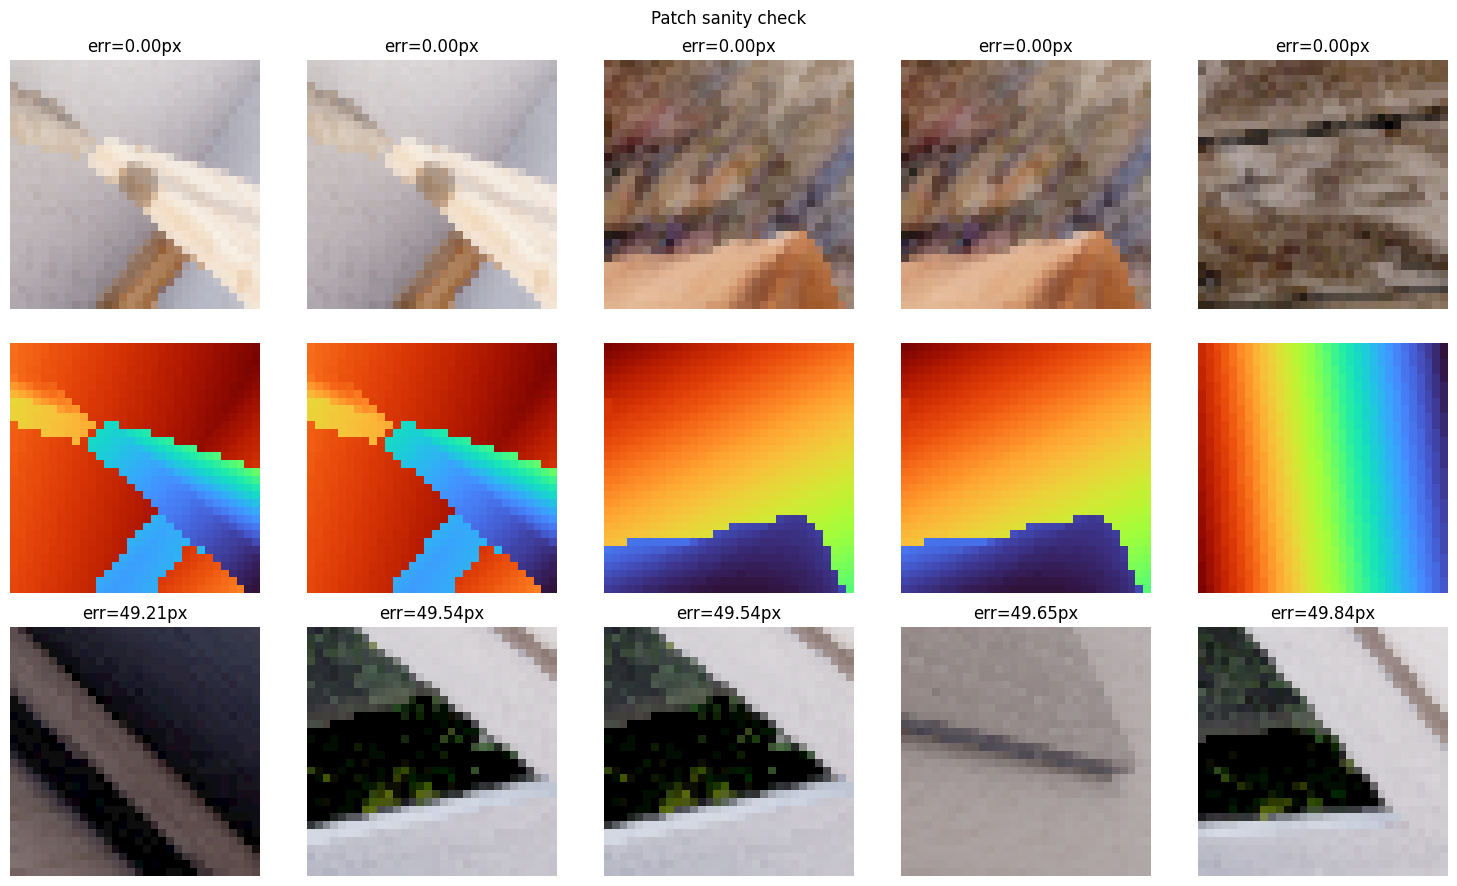

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
# pick 5 low-error and 5 high-error samples
low_idx = np.argsort(d["reproj_error"])[:5]
high_idx = np.argsort(d["reproj_error"])[-5:]

for col, i in enumerate(low_idx):
    axes[0, col].imshow(d["img_patch"][i])
    axes[0, col].set_title(f"err={d['reproj_error'][i]:.2f}px")
    axes[0, col].axis("off")
    axes[1, col].imshow(d["depth_patch"][i], cmap="turbo")
    axes[1, col].axis("off")

for col, i in enumerate(high_idx):
    axes[2, col].imshow(d["img_patch"][i])
    axes[2, col].set_title(f"err={d['reproj_error'][i]:.2f}px")
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Low error")
axes[1, 0].set_ylabel("Depth (low err)")
axes[2, 0].set_ylabel("High error")
plt.suptitle("Patch sanity check")
plt.tight_layout()
plt.show()

Depth range: 0.20 – 50.00 m
Mean: 4.01, Median: 2.11


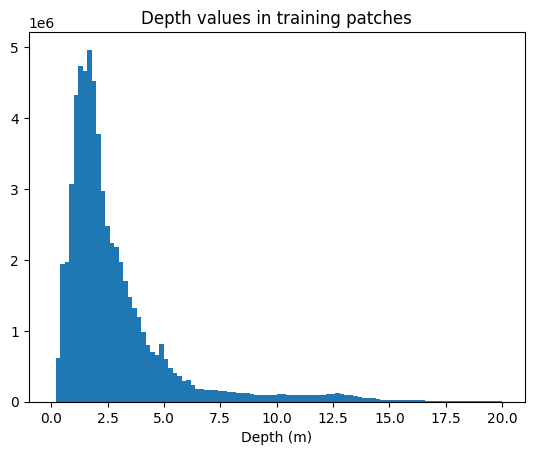

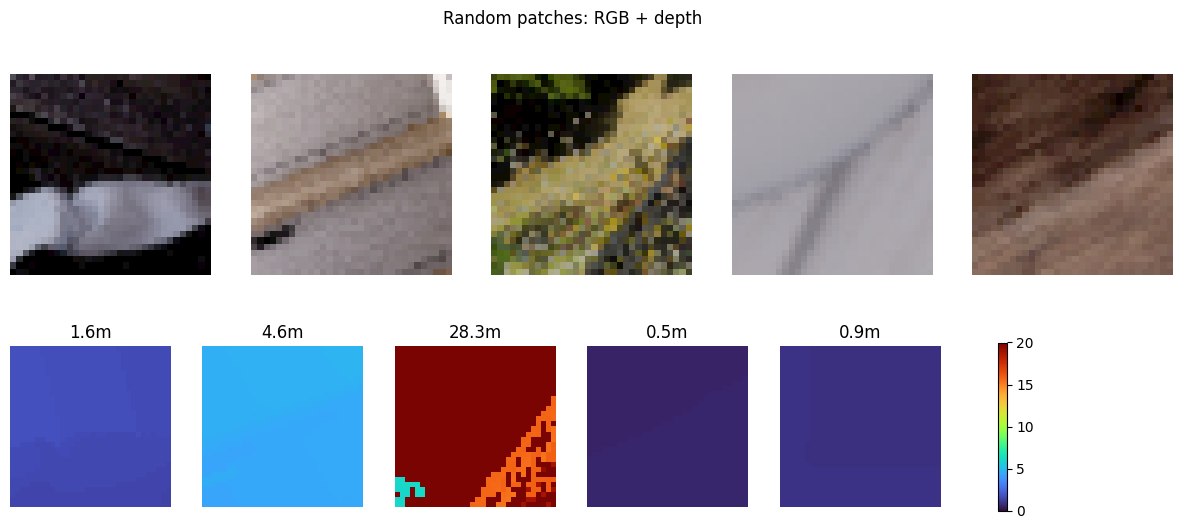

In [13]:
depths = d["depth_patch"]

# overall stats (ignoring NaN)
valid = depths[~np.isnan(depths) & (depths > 0)]
print(f"Depth range: {valid.min():.2f} – {valid.max():.2f} m")
print(f"Mean: {valid.mean():.2f}, Median: {np.median(valid):.2f}")

# histogram
plt.hist(valid.ravel(), bins=100, range=(0, 20))
plt.xlabel("Depth (m)")
plt.title("Depth values in training patches")
plt.show()

# spot check a few patches
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for col in range(5):
    idx = np.random.randint(len(depths))
    axes[0, col].imshow(d["img_patch"][idx])
    axes[0, col].axis("off")
    im = axes[1, col].imshow(depths[idx], cmap="turbo", vmin=0, vmax=20)
    axes[1, col].set_title(f"{np.nanmean(depths[idx]):.1f}m")
    axes[1, col].axis("off")
plt.colorbar(im, ax=axes[1, :].tolist(), shrink=0.8)
plt.suptitle("Random patches: RGB + depth")
plt.show()

Found 1512 straddling matches total


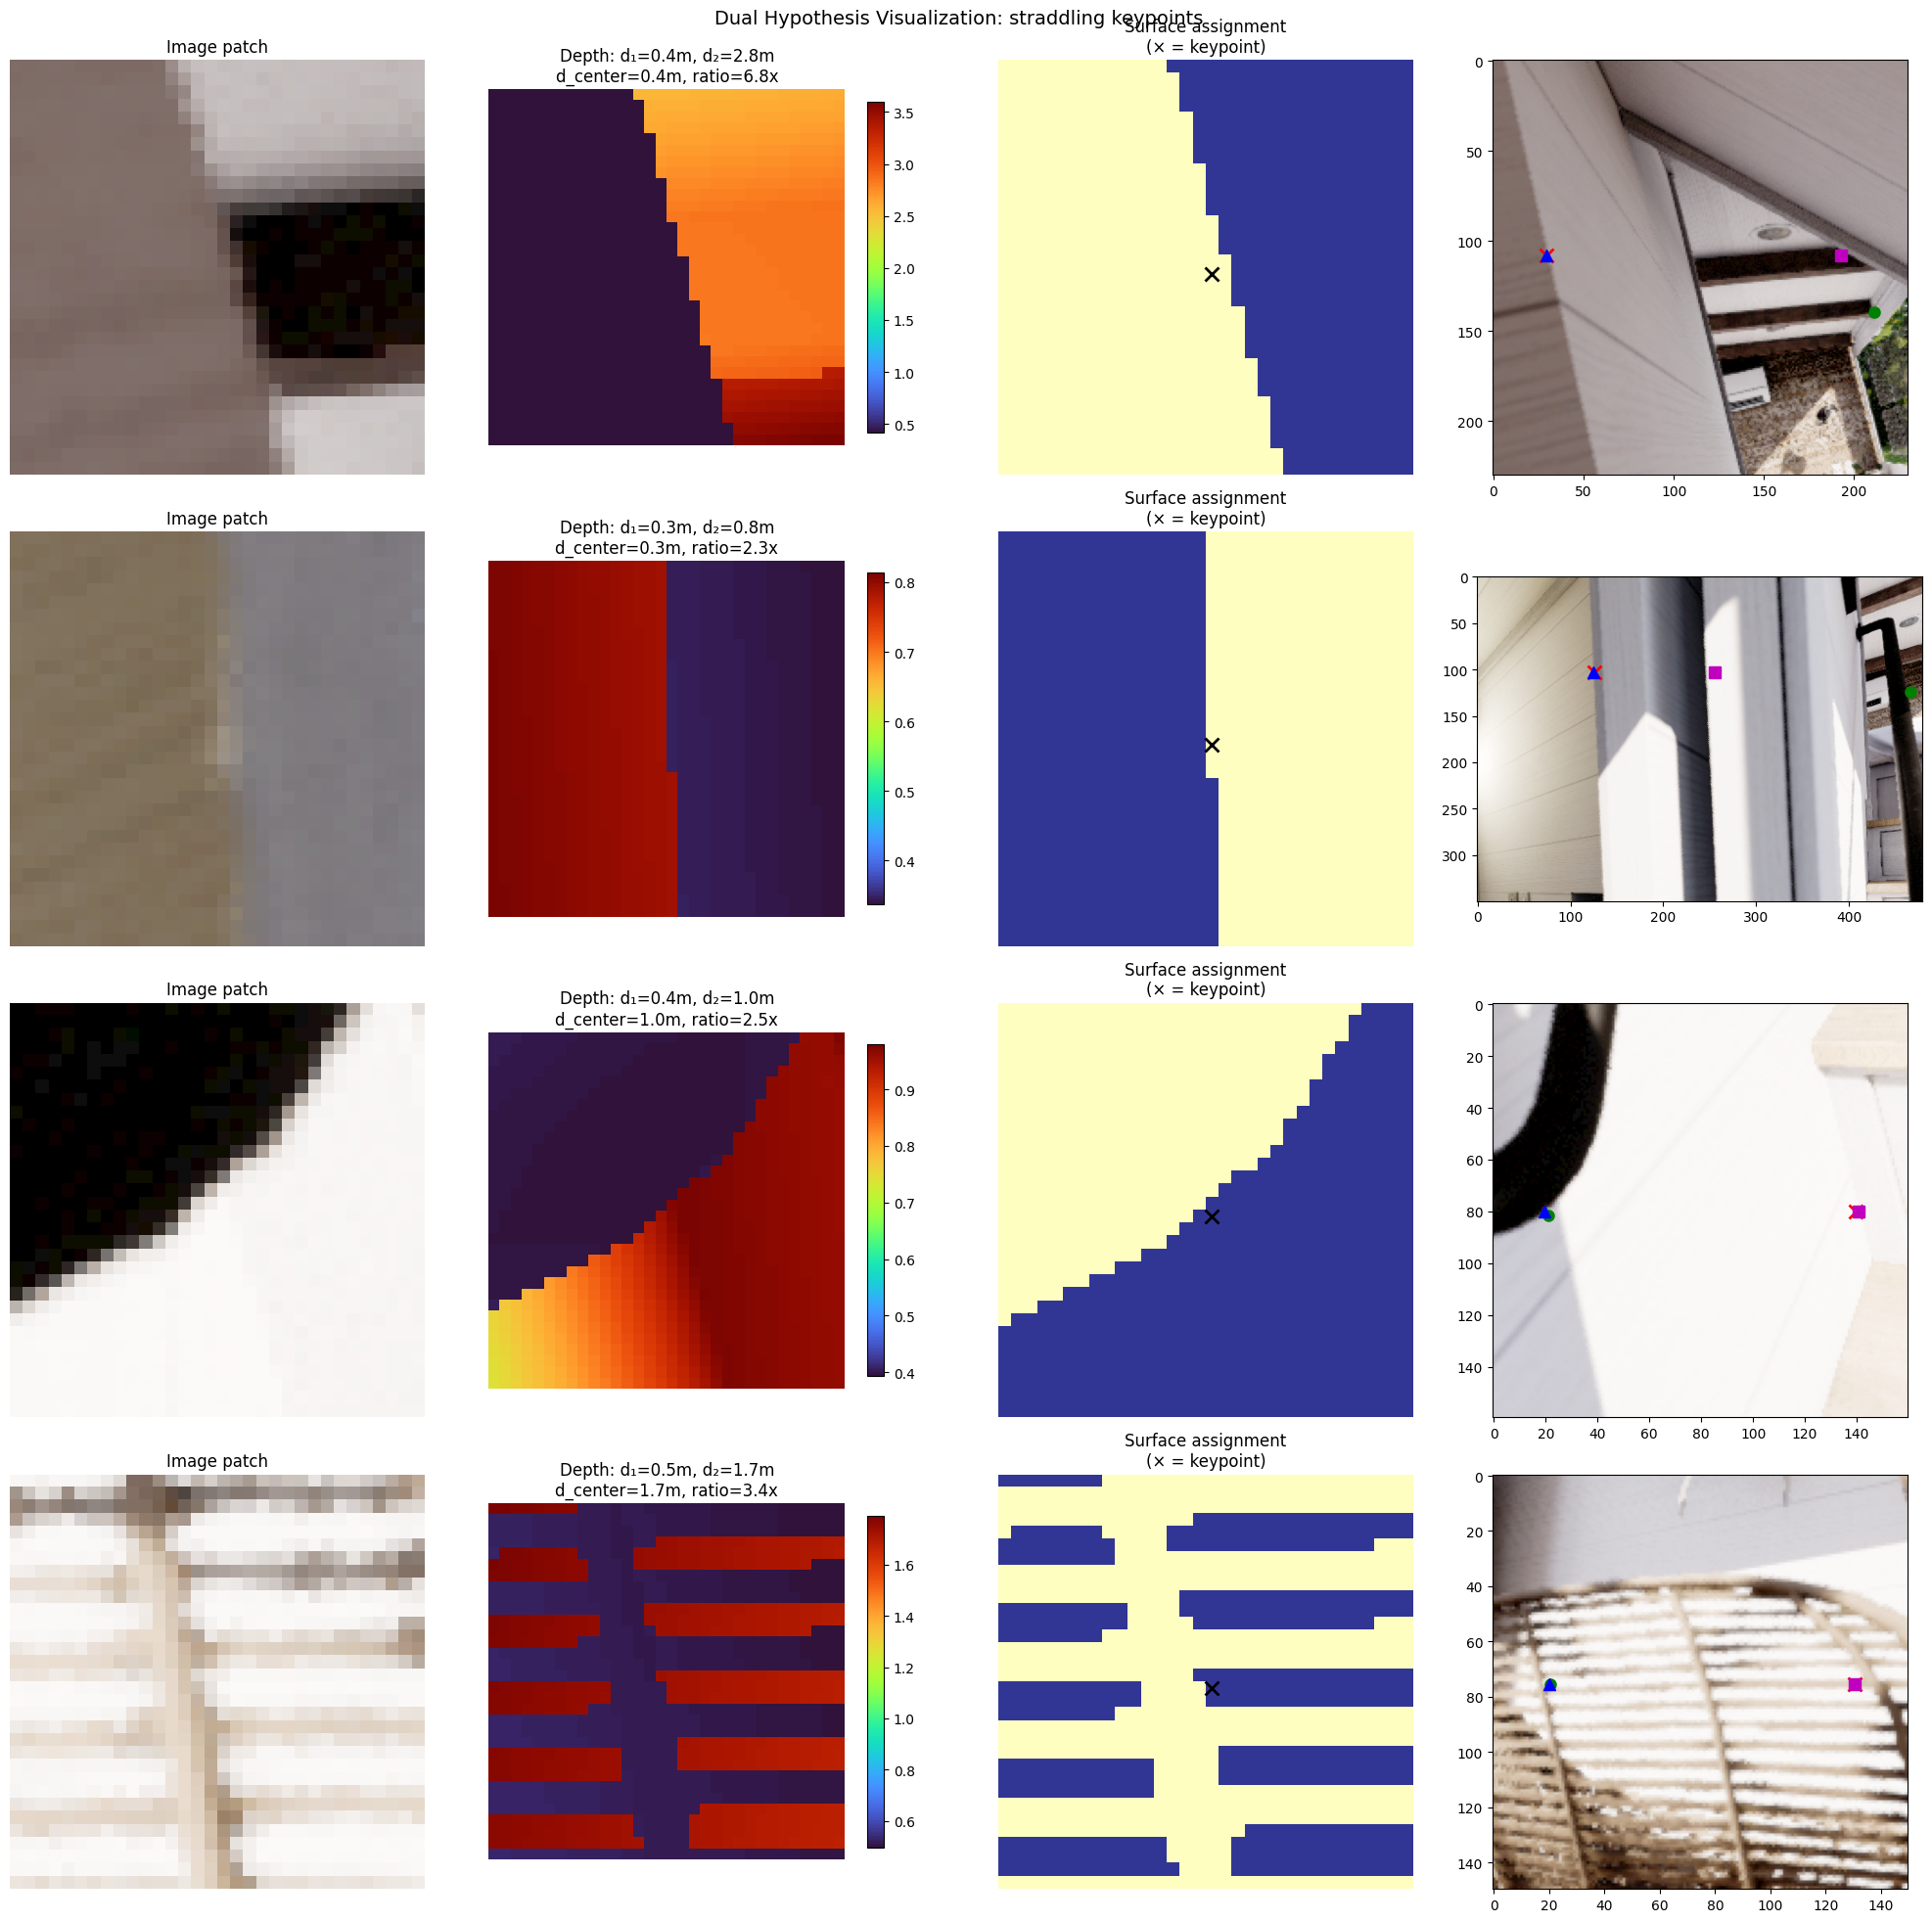

In [18]:
cases = []

for seq in ["P000", "P001", "P002", "P003", "P004", "P005", "P006"]:
    seq_dir = base / seq
    n_frames = len([f for f in (seq_dir / "image_lcam_front").glob("*_lcam_front.png")
                    if not f.name.startswith(".")])

    for frame_idx in range(0, n_frames):  
        img_l = np.array(Image.open(seq_dir / "image_lcam_front" / f"{frame_idx:06d}_lcam_front.png"))
        img_r = np.array(Image.open(seq_dir / "image_rcam_front" / f"{frame_idx:06d}_rcam_front.png"))
        depth_l = read_decode_depth(str(seq_dir / "depth_lcam_front" / f"{frame_idx:06d}_lcam_front_depth.png"))
        depth_l = depth_l.astype(np.float32)
        depth_l[depth_l > 15.0] = np.nan

        good_matches, kps1, kps2, _ = match(img_l, img_r, K=K)

        for m in good_matches:
            pt_a = np.array(kps1[m.queryIdx].pt)
            pt_b_obs = np.array(kps2[m.trainIdx].pt)

            d_a = sample_depth_nn(depth_l, pt_a)
            if np.isnan(d_a) or d_a <= 0:
                continue
            tiny = extract_patch(depth_l, pt_a, size=7)
            if tiny is None:
                continue
            tiny = tiny.astype(np.float32)
            valid_tiny = tiny[~np.isnan(tiny) & (tiny > 0)]
            
            d1 = np.percentile(valid_tiny, 10)   # robust foreground
            d2 = np.percentile(valid_tiny, 90)   # robust background
            
            if d2 / d1 < 1.3:
                continue
            if abs(d2 - d1) < 0.3:
                continue

            mid = (d1 + d2) / 2
            n_fg = np.sum(valid_tiny < mid)
            n_bg = np.sum(valid_tiny >= mid)
            min_ratio = min(n_fg, n_bg) / len(valid_tiny)
            if min_ratio < 0.10:  # at least 10% of pixels on each surface
                continue

            e_c = np.linalg.norm(pt_b_obs - project_point_tartanair(
                transform_point(back_project(pt_a, d_a, K), T_lr), K))
            e_1 = np.linalg.norm(pt_b_obs - project_point_tartanair(
                transform_point(back_project(pt_a, d1, K), T_lr), K))
            e_2 = np.linalg.norm(pt_b_obs - project_point_tartanair(
                transform_point(back_project(pt_a, d2, K), T_lr), K))

            improvement = e_c - min(e_1, e_2)

            cases.append({
                "pt_a": pt_a, "pt_b_obs": pt_b_obs, "d_a": d_a,
                "d1": d1, "d2": d2, "e_c": e_c, "e_1": e_1, "e_2": e_2,
                "improvement": improvement,
                "proj_c": project_point_tartanair(transform_point(back_project(pt_a, d_a, K), T_lr), K),
                "proj_1": project_point_tartanair(transform_point(back_project(pt_a, d1, K), T_lr), K),
                "proj_2": project_point_tartanair(transform_point(back_project(pt_a, d2, K), T_lr), K),
                "seq": seq, "frame": frame_idx,
                "img_l": img_l, "depth_l": depth_l, "img_r": img_r,
            })


cases.sort(key=lambda c: c["improvement"], reverse=True)
print(f"Found {len(cases)} straddling matches total")

# Visualize top 4
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for row, c in enumerate(cases[:4]):
    pt = c["pt_a"]
    half = 16
    img_l = c["img_l"]
    depth_l = c["depth_l"]
    img_r = c["img_r"]

    # col 0: image patch
    axes[row, 0].imshow(img_l[int(pt[1])-half:int(pt[1])+half,
                               int(pt[0])-half:int(pt[0])+half])
    axes[row, 0].set_title(f"Image patch")
    axes[row, 0].axis("off")

    # col 1: depth patch with values
    d_patch = depth_l[int(pt[1])-half:int(pt[1])+half,
                      int(pt[0])-half:int(pt[0])+half]
    im = axes[row, 1].imshow(d_patch, cmap="turbo")
    axes[row, 1].set_title(f"Depth: d₁={c['d1']:.1f}m, d₂={c['d2']:.1f}m\n"
                           f"d_center={c['d_a']:.1f}m, ratio={c['d2']/c['d1']:.1f}x")
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], shrink=0.8)

    # col 2: depth patch thresholded to show two surfaces
    mid = (c["d1"] + c["d2"]) / 2
    surface_map = np.where(d_patch < mid, 1, 2)
    surface_map = np.where(np.isnan(d_patch), 0, surface_map)
    axes[row, 2].imshow(surface_map, cmap="RdYlBu", vmin=0, vmax=2)
    axes[row, 2].plot(half, half, "kx", markersize=10, markeredgewidth=2)  # keypoint
    axes[row, 2].set_title(f"Surface assignment\n(× = keypoint)")
    axes[row, 2].axis("off")

    # col 3: right image with projections
    all_pts = np.array([c["pt_b_obs"], c["proj_c"], c["proj_1"], c["proj_2"]])
    center = all_pts.mean(axis=0)
    spread = np.max(np.abs(all_pts - center)) + 20  # padding
    r_half = max(40, int(spread))

    cx, cy = int(center[0]), int(center[1])
    y_min = max(0, cy - r_half)
    y_max = min(img_r.shape[0], cy + r_half)
    x_min = max(0, cx - r_half)
    x_max = min(img_r.shape[1], cx + r_half)
    r_patch = img_r[y_min:y_max, x_min:x_max]
    axes[row, 3].imshow(r_patch)

    ox, oy = x_min, y_min
    axes[row, 3].plot(c["pt_b_obs"][0]-ox, c["pt_b_obs"][1]-oy, "go", ms=8, label=f"SIFT match")
    axes[row, 3].plot(c["proj_c"][0]-ox, c["proj_c"][1]-oy, "rx", ms=10, mew=2, label=f"d_center ({c['e_c']:.1f}px)")
    axes[row, 3].plot(c["proj_1"][0]-ox, c["proj_1"][1]-oy, "b^", ms=8, label=f"d₁ fg ({c['e_1']:.1f}px)")
    axes[row, 3].plot(c["proj_2"][0]-ox, c["proj_2"][1]-oy, "ms", ms=8, label=f"d₂ bg ({c['e_2']:.1f}px)")

plt.suptitle("Dual Hypothesis Visualization: straddling keypoints", fontsize=14)
plt.tight_layout()
plt.savefig("dual_hypothesis_examples.png", dpi=150)
plt.show()

In [15]:
            # save lightweight results
save_data = {
    "straddling_score": np.array([c["d2"]/c["d1"] for c in cases]),
    "e_center": np.array([c["e_c"] for c in cases]),
    "e_fg": np.array([c["e_1"] for c in cases]),
    "e_bg": np.array([c["e_2"] for c in cases]),
    "e_best": np.array([min(c["e_1"], c["e_2"]) for c in cases]),
    "d_center": np.array([c["d_a"] for c in cases]),
    "d1": np.array([c["d1"] for c in cases]),
    "d2": np.array([c["d2"] for c in cases]),
    "improvement": np.array([c["improvement"] for c in cases]),
}
np.savez_compressed("dual_hypothesis_results.npz", **save_data)
print(f"Saved {len(cases)} samples")

Saved 1501 samples


In [16]:
r = np.load("dual_hypothesis_results.npz")
s = r["straddling_score"]
e_c = r["e_center"]
e_b = r["e_best"]
imp = r["improvement"]

thresholds = [1.3, 1.5, 2.0, 3.0, 5.0]

print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Dual hypothesis improvement by depth discontinuity severity}")
print(r"\label{tab:dual-hyp}")
print(r"\begin{tabular}{cccccc}")
print(r"\toprule")
print(r"Depth ratio & $n$ & Med. $e_\text{center}$ & Med. $e_\text{best}$ & Med. improvement & \% improved \\")
print(r"\midrule")

for i, t in enumerate(thresholds):
    t_upper = thresholds[i+1] if i+1 < len(thresholds) else np.inf
    mask = (s >= t) & (s < t_upper)
    n = mask.sum()
    if n < 5:
        continue
    med_c = np.median(e_c[mask])
    med_b = np.median(e_b[mask])
    med_i = np.median(imp[mask])
    pct = np.mean(e_b[mask] < e_c[mask]) * 100
    upper_str = f"{t_upper:.1f}" if t_upper != np.inf else r"$\infty$"
    print(f"{t:.1f}--{upper_str} & {n} & {med_c:.2f} & {med_b:.2f} & {med_i:.2f} & {pct:.1f}\\% \\\\")

# also print the overall high-straddling row
mask_high = s >= 2.0
n_h = mask_high.sum()
print(r"\midrule")
print(f"$\\geq 2.0$ (all) & {n_h} & {np.median(e_c[mask_high]):.2f} & {np.median(e_b[mask_high]):.2f} & {np.median(imp[mask_high]):.2f} & {np.mean(e_b[mask_high] < e_c[mask_high])*100:.1f}\\% \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

\begin{table}[h]
\centering
\caption{Dual hypothesis improvement by depth discontinuity severity}
\label{tab:dual-hyp}
\begin{tabular}{cccccc}
\toprule
Depth ratio & $n$ & Med. $e_\text{center}$ & Med. $e_\text{best}$ & Med. improvement & \% improved \\
\midrule
1.3--1.5 & 759 & 2.71 & 1.10 & 0.13 & 61.7\% \\
1.5--2.0 & 466 & 4.71 & 1.42 & 0.24 & 67.8\% \\
2.0--3.0 & 166 & 6.91 & 2.10 & 0.19 & 61.4\% \\
3.0--5.0 & 84 & 22.63 & 1.34 & 12.18 & 73.8\% \\
5.0--$\infty$ & 26 & 21.73 & 4.94 & 0.04 & 53.8\% \\
\midrule
$\geq 2.0$ (all) & 276 & 12.06 & 1.89 & 0.36 & 64.5\% \\
\bottomrule
\end{tabular}
\end{table}


In [46]:
def backproj(u, v, d, c, f):
    return np.array([d*(u - c)/f, d*(v - c)/f, d])

def proj(x, y, z, c, f):
    return np.array([f*x/z + c, f*y/z + c])

c, f = 320, 320
b = 0.25  # stereo baseline

# same keypoint at pixel (200, 300), two different depths
u, v = 200, 300
d_fg = 0.4   # foreground
d_bg = 1.0   # background (missampled)

# back-project with each depth
pt_fg = backproj(u, v, d_fg, c, f)
pt_bg = backproj(u, v, d_bg, c, f)

# transform to right camera (pure horizontal translation)
pt_fg_r = pt_fg + np.array([b, 0, 0])  # or [0, b, 0] depending on convention
pt_bg_r = pt_bg + np.array([b, 0, 0])

# project into right image
px_fg = proj(pt_fg_r[0], pt_fg_r[1], pt_fg_r[2], c, f)
px_bg = proj(pt_bg_r[0], pt_bg_r[1], pt_bg_r[2], c, f)

print(f"3D error: {np.linalg.norm(pt_fg - pt_bg):.3f} m")
print(f"2D error: {np.linalg.norm(px_fg - px_bg):.1f} px")
print(f"Foreground projects to: {px_fg}")
print(f"Background projects to: {px_bg}")

3D error: 0.642 m
2D error: 120.0 px
Foreground projects to: [400. 300.]
Background projects to: [280. 300.]


In [47]:
u, v = 200, 300
c, f, b = 320, 320, 0.25

print(f"{'d_fg':>6s} {'d_bg':>6s} {'3D err':>8s} {'2D err':>8s}")
print("-" * 35)
for d_fg, d_bg in [(0.4, 1.0), (1.0, 1.5), (2.0, 2.3), 
                    (2.0, 2.1), (3.0, 3.2), (5.0, 5.5),
                    (5.0, 5.1), (8.0, 8.2)]:
    pt_fg = backproj(u, v, d_fg, c, f)
    pt_bg = backproj(u, v, d_bg, c, f)
    pt_fg_r = pt_fg + np.array([b, 0, 0])
    pt_bg_r = pt_bg + np.array([b, 0, 0])
    px_fg = proj(pt_fg_r[0], pt_fg_r[1], pt_fg_r[2], c, f)
    px_bg = proj(pt_bg_r[0], pt_bg_r[1], pt_bg_r[2], c, f)
    e3d = np.linalg.norm(pt_fg - pt_bg)
    e2d = np.linalg.norm(px_fg - px_bg)
    print(f"{d_fg:6.1f} {d_bg:6.1f} {e3d:7.3f}m {e2d:7.1f}px")

  d_fg   d_bg   3D err   2D err
-----------------------------------
   0.4    1.0   0.642m   120.0px
   1.0    1.5   0.535m    26.7px
   2.0    2.3   0.321m     5.2px
   2.0    2.1   0.107m     1.9px
   3.0    3.2   0.214m     1.7px
   5.0    5.5   0.535m     1.5px
   5.0    5.1   0.107m     0.3px
   8.0    8.2   0.214m     0.2px


In [14]:
import open3d as o3d
from pathlib import Path
import numpy as np
# floater analysis
path = Path("/Volumes/T9/datasets/tanks-and-temples/meetingroom")
pcd_gt = o3d.io.read_point_cloud(path / "Meetingroom.ply")
pcd_colmap = o3d.io.read_point_cloud(path / "Meetingroom_COLMAP.ply")

In [15]:
o3d.visualization.draw_geometries([pcd_colmap])

In [16]:
# Load alignment
alignment = np.loadtxt(path / "Meetingroom_trans.txt")

# Align COLMAP to GT frame
colmap_pts = np.asarray(pcd_colmap.points)
colmap_homo = np.hstack([colmap_pts, np.ones((len(colmap_pts), 1))])
colmap_aligned = (alignment @ colmap_homo.T).T[:, :3]

# Crop to evaluation region
import json
from matplotlib.path import Path as MplPath

with open(path / "Meetingroom.json") as f:
    crop = json.load(f)

poly = np.array(crop["bounding_polygon"])[:, :2]
z_min = crop["axis_min"]
z_max = crop["axis_max"]

polygon_path = MplPath(poly)
xy_inside = polygon_path.contains_points(colmap_aligned[:, :2])
z_inside = (colmap_aligned[:, 2] >= z_min) & (colmap_aligned[:, 2] <= z_max)
inside = xy_inside & z_inside

cropped_pts = colmap_aligned[inside]
print(f"Before crop: {len(colmap_aligned)}")
print(f"After crop: {len(cropped_pts)}")

# Compute distances to GT for cropped points only
pcd_cropped = o3d.geometry.PointCloud()
pcd_cropped.points = o3d.utility.Vector3dVector(cropped_pts)
if pcd_colmap.has_colors():
    colmap_colors = np.asarray(pcd_colmap.colors)
    pcd_cropped.colors = o3d.utility.Vector3dVector(colmap_colors[inside])
dists = np.asarray(pcd_cropped.compute_point_cloud_distance(pcd_gt))
# Color original, then override floaters with red
colors = np.asarray(pcd_cropped.colors).copy()
floater_mask = dists >= 0.3  # use 0.3m to catch the moderate floaters too
colors[floater_mask] = [1, 0, 0]
pcd_cropped.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd_cropped])
for t in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]:
    n = (dists >= t).sum()
    pct = n / len(dists) * 100
    print(f">{t:.1f}m: {n:>8d} ({pct:.2f}%)")

print(f"\nDistance stats (cropped):")
print(f"Median: {np.median(dists):.4f}")
print(f"p90: {np.percentile(dists, 90):.4f}")
print(f"p95: {np.percentile(dists, 95):.4f}")
print(f"p99: {np.percentile(dists, 99):.4f}")


Before crop: 5509866
After crop: 5391931
>0.1m:  4123719 (76.48%)
>0.1m:  2964726 (54.98%)
>0.2m:  1291530 (23.95%)
>0.5m:    37622 (0.70%)
>1.0m:     9448 (0.18%)
>2.0m:     1531 (0.03%)
>5.0m:        0 (0.00%)

Distance stats (cropped):
Median: 0.1125
p90: 0.2831
p95: 0.3388
p99: 0.4639


In [11]:
# Isolate the floaters and visualize
floater_mask = dists >= 0.5
surface_mask = dists < 0.05

# Show floaters in red, surface in transparent gray
colors = np.ones((len(dists), 3)) * 0.7  # gray
colors[floater_mask] = [1, 0, 0]
pcd_cropped.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd_cropped])

# Or show ONLY floaters to see where they cluster
pcd_floaters = o3d.geometry.PointCloud()
pcd_floaters.points = o3d.utility.Vector3dVector(cropped_pts[floater_mask])
pcd_floaters.paint_uniform_color([1, 0, 0])

# Show floaters against GT surface
o3d.visualization.draw_geometries([pcd_floaters, pcd_gt],
                                   window_name="Floaters only (red) vs GT (blue)")

In [ ]:
# Visualize aligned COLMAP (all points, with original colors) against GT
pcd_full_aligned = o3d.geometry.PointCloud()
pcd_full_aligned.points = o3d.utility.Vector3dVector(colmap_aligned)
if pcd_colmap.has_colors():
    pcd_full_aligned.colors = pcd_colmap.colors

o3d.visualization.draw_geometries([pcd_full_aligned, pcd_gt_vis],
                                   window_name="Full aligned COLMAP vs GT")